In [1]:
from simulation import populations

# differents team models
ecosystem1 = populations.from_gpr_level()
ecosystem2 = populations.datadriven("gaussian")
ecosystem3 = populations.datadriven("weibull")

# display the population
for region in ecosystem1.regions():
    print(region, len(ecosystem1.teams(region)))

print("number of teams: ", len(ecosystem1.teams()))

LTAN 8
LEC 10
LCK 10
LPL 17
LCP 17
LTAS 16
number of teams:  78


In [2]:
from project.scheduler.calendar import year_schedule, calendar, event_qualification
from project.scene import Split, Finals
from project.gpr.utils import GameHistory, Modes, get_event_infos

from rstt import LogSolver, BTRanking

solver = LogSolver()
ecosystem = ecosystem1

start = 2024
duration = 50

event_per_year = len(year_schedule(start, start+duration)) // duration
stage_per_event = 3
team_years, league_years = 3, 2

window_ranges = {Modes.Team: team_years * event_per_year * stage_per_event,
                 Modes.League: league_years * event_per_year * stage_per_event}
dataset = GameHistory(mode_range=window_ranges)

In [3]:
# Simulation
games = []
for event in calendar(start, start+duration, solver, seeding=BTRanking(), source='data/qualifications.json'):
    infos = get_event_infos(event)
    invitations, qualifications = event_qualification(infos, ecosystem, dataset, source='data/qualifications.json')
    event.registration(invited=invitations, qualified=qualifications)
    event.run()
    
    for stage in event.stages:
        dataset.add(stage)
        games += stage.games()
len(games)

/Users/dbucher/Documents/GitHub/rstt/rstt/utils/competition.py:46: RuntimeWarning: No Valid matchups where found
  warnings.warn(msg, RuntimeWarning)


92400

In [4]:
from rstt import RandomRound

nb_event_year = event_per_year * stage_per_event
random_data = RandomRound('OneBigRegion', BTRanking(), solver,
                            rounds=nb_event_year, amount=round(len(games) / nb_event_year))
random_data.registration(ecosystem.teams())
random_data.run()
len(random_data.games())

2457

In [5]:
from rstt import BasicElo
from project import GlobalRanking

gt = BTRanking(name='GroundTruth', players=ecosystem.teams())

elo_lol = BasicElo(name='Elo Lol Pro Scene', players=ecosystem.teams())
elo_baseline = BasicElo(name='Elo Random Games', players=ecosystem.teams())

#gpr_lol = GlobalRanking('GPR Lol Pro Scene', ecosystem=ecosystem)
#gpr_baseline = GlobalRanking('GPR Random Games', ecosystem=ecosystem)

In [6]:
from scipy import stats
import pandas as pd

systems = [(elo_lol, games), (elo_baseline, random_data.games())]

df_data = {'teams': [team.name() for team in ecosystem.teams()]}
df_data.update({f"{elo.name} 0": [elo.point(team) for team in ecosystem.teams()]
                 for (elo,_) in systems})

columns = {}
for (elo, data) in systems:
    for i, game in enumerate(data):
        elo.update(game=game)
        df_data[f"{elo.name} {i+1}"] = elo[ecosystem.teams()]

In [7]:
ratings = pd.DataFrame(df_data)
corrs = {elo.name: [stats.kendalltau(gt[ecosystem.teams()], ratings[f"{elo.name} {i}"]).statistic 
                    for i in range(min(len(games), len(random_data.games())))]
         for (elo,_) in systems}

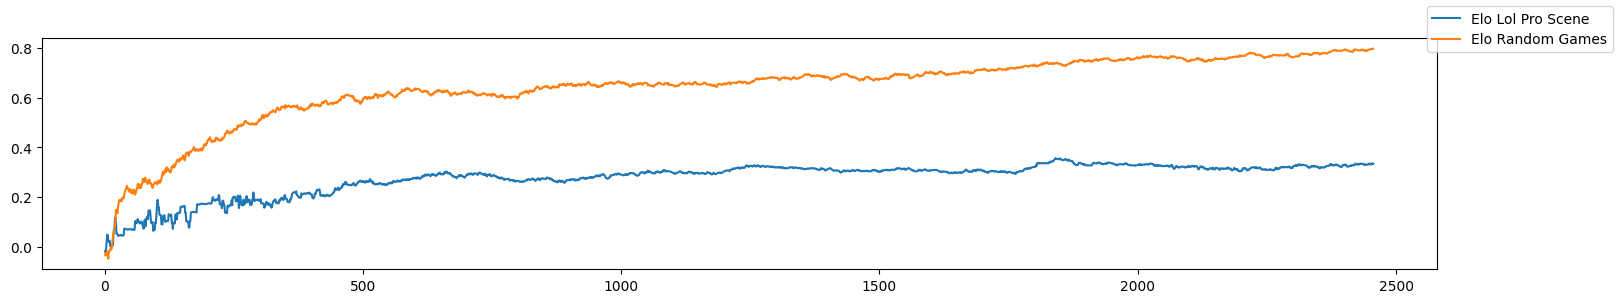

In [8]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(18, 3))

for elo in corrs.keys():
    plt.plot(corrs[elo], label=elo)
fig.legend()
plt.show()

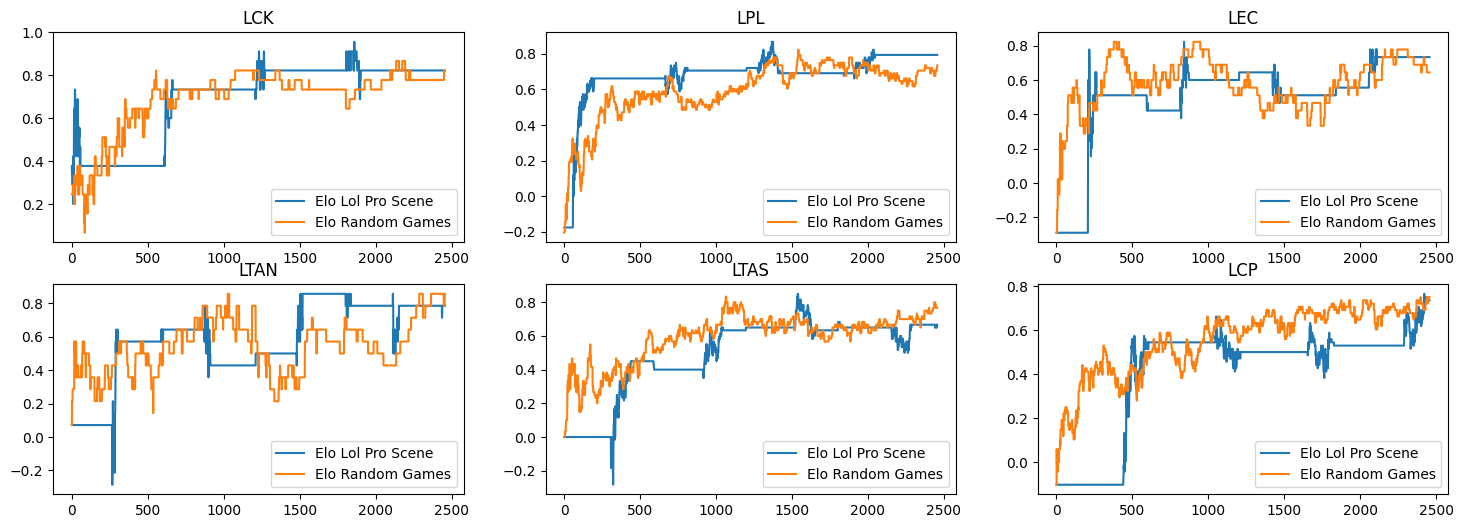

In [9]:
from project.scene import Region

n_games = min(len(games), len(random_data.games()))

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 6))
for ax, region in zip(axes.flat, Region):
    teams_name = [team.name() for team in ecosystem.teams(region)]
    regional_ratings = ratings.set_index('teams').loc[teams_name]
    gt_region = gt[ecosystem.teams(region)]

    regional_corrs = {
        elo.name: [
            stats.kendalltau(gt_region, regional_ratings[f"{elo.name} {i}"]).statistic
            for i in range(n_games)
        ]
        for elo, _ in systems
    }

    for name, corr in regional_corrs.items():
        ax.plot(corr, label=name)
    ax.set_title(region.name)
    ax.legend()

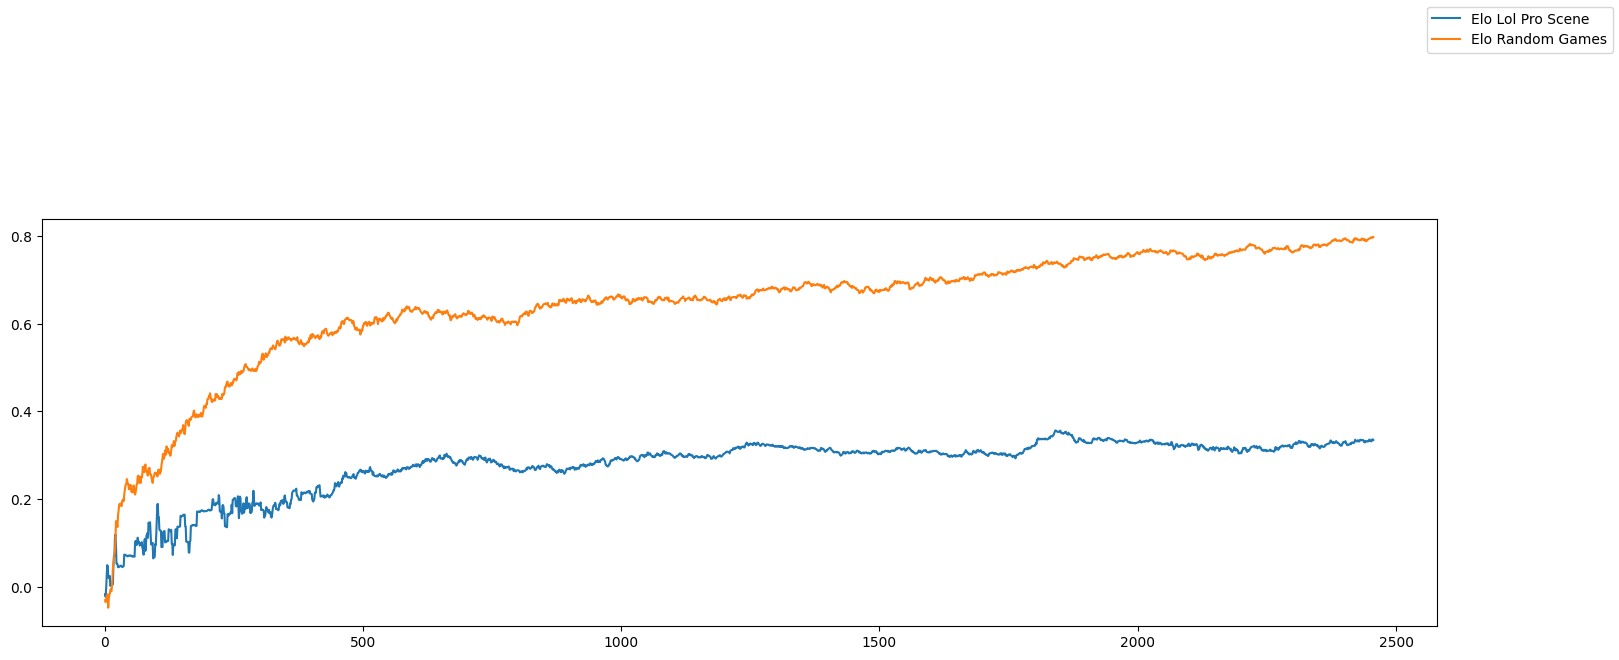

Axes(0.125,0.381765;0.227941x0.226471)
Axes(0.398529,0.381765;0.227941x0.226471)
Axes(0.672059,0.381765;0.227941x0.226471)
Axes(0.125,0.11;0.227941x0.226471)
Axes(0.398529,0.11;0.227941x0.226471)
Axes(0.672059,0.11;0.227941x0.226471)


In [10]:
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(18,18))

gs = gridspec.GridSpec(3, 3, fig)
ax0 = plt.subplot(gs[0, :])

for elo in corrs.keys():
    ax0.plot(corrs[elo], label=elo)
fig.legend()
plt.show()

gs.subplots()[1:, :].flatten()
for ax in gs.subplots()[1:, :].flatten():
    print(ax)

In [11]:
import scipy.stats

df1 = pd.DataFrame({region: stats.describe([t.level() for t in ecosystem1.teams(region)])._asdict() for region in Region})
df2 = pd.DataFrame({region: stats.describe([t.level() for t in ecosystem2.teams(region)])._asdict() for region in Region})
df3 = pd.DataFrame({region: stats.describe([t.level() for t in ecosystem3.teams(region)])._asdict() for region in Region})

In [12]:
wb_datadriven_teams = {
    region: Player.create(nb=len(data_ecosystem.teams(region)), 
                          level_dist=stats.weibull_min,
                          level_params=stats.fit(dist=stats.weibull_min,
                                                 data=[t.level() for t in data_ecosystem.teams(region)],
                                                 bounds={"c": (1, 50)}).params._asdict() | {'size': 1})
    for region in Region
}
wb_datadriven = LeagueSystem(wb_datadriven_teams)
plt.hist(sorted([t.level() for t in wb_datadriven.teams(Region.LCP)]))

NameError: name 'Player' is not defined

In [ ]:
func=stats.weibull_min
wb_data_teams = {region: Player.create(nb=len(data_ecosystem.teams(region)),
                                level_dist=lambda values=func.rvs(**stats.fit(func, 
                                                                          [t.level() for t in data_ecosystem.teams(region)],
                                                                          bounds={"c": (0.001, 100)}).params._asdict(), size=len(data_ecosystem.teams(region))): values.pop(0)
                                )
           for region in Region
          }
wb_data = LeagueSystem(wb_data_teams)
plt.hist(sorted([t.level() for t in wb_data.teams(Region.LCP)]))

In [ ]:
ranking1 = BTRanking("Ranking1", players=ecosystem1.teams())
ranking2 = BTRanking("Ranking1", players=ecosystem2.teams())
ranking3 = BTRanking("Ranking1", players=ecosystem3.teams())

In [ ]:
ranking3.plot()